In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("playlists_dev.db")

# # Show first 5 playlists
# df_playlists = pd.read_sql("SELECT * FROM playlists LIMIT 5", conn)
# print("Playlists:")
# print(df_playlists)

# # Show some tracks
# df_tracks = pd.read_sql("SELECT * FROM tracks LIMIT 5", conn)
# print("\nTracks:")
# print(df_tracks)

# # Show playlist-track mappings
# df_links = pd.read_sql("SELECT * FROM playlist_track LIMIT 5", conn)
# print("\nPlaylist-Track Links:")
# print(df_links)
print("Playlist count:", pd.read_sql("SELECT COUNT(*) FROM playlists;", conn).iloc[0, 0])
print("Track count:", pd.read_sql("SELECT COUNT(*) FROM tracks;", conn).iloc[0, 0])
print("Links count:", pd.read_sql("SELECT COUNT(*) FROM playlist_track;", conn).iloc[0, 0])
conn.close()


Playlist count: 1000
Track count: 34443
Links count: 66721


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('playlists_dev.db')

# Updated query with track_name and artist_name
query = """
CREATE TABLE IF NOT EXISTS track_summary AS
SELECT
    pt.track_uri,
    t.track_name,
    t.artist_name,
    COUNT(DISTINCT pt.pid) AS in_number_of_playlists,
    AVG(p.num_followers) AS avg_playlist_followers,
    AVG(pt.pos) AS avg_position_in_playlist
FROM playlist_track pt
JOIN playlists p ON pt.pid = p.pid
JOIN tracks t ON pt.track_uri = t.track_uri
GROUP BY pt.track_uri;
"""

# Run query
conn.execute(query)
conn.commit()

# Load result into pandas DataFrame
df_summary = pd.read_sql_query("SELECT * FROM track_summary", conn)
print(df_summary.head())

# Close connection
conn.close()


                              track_uri                        track_name  \
0  spotify:track:000mA0etY38nKdvf1N04af  If I Gave Myself To Someone Else   
1  spotify:track:000xQL6tZNLJzIrtIgxqSl                    Still Got Time   
2  spotify:track:006AVH7fq061voGXkUiII4                        Fingertips   
3  spotify:track:006PJvsr6CyV3JdBf7wiNF             Crumble the Satellite   
4  spotify:track:006yrnQMCZpiUgkR612gC8                           Caliber   

          artist_name  in_number_of_playlists  avg_playlist_followers  \
0         The Coronas                       1                     1.0   
1                ZAYN                       2                     3.0   
2  Ryan O'Shaughnessy                       1                     1.0   
3           Paul Wall                       1                     1.0   
4           Desiigner                       1                     1.0   

   avg_position_in_playlist  
0                      12.0  
1                      58.0  
2       

In [4]:
conn = sqlite3.connect('playlists_dev.db')
df_titles = pd.read_sql_query("SELECT pid, name FROM playlists", conn)
conn.close()

In [ ]:
import re
from nltk.corpus import stopwords
from collections import Counter
import nltk
nltk.download('stopwords')

# Basic text cleanup function
def clean_title(title):
    title = title.lower()
    title = re.sub(r'[^a-z0-9\s]', '', title)  # Remove punctuation
    tokens = title.split()
    tokens = [t for t in tokens if t not in stopwords.words('english')]
    return tokens

# Apply and build keyword list
df_titles["tokens"] = df_titles["name"].fillna("").apply(clean_title)

# Flatten all tokens for frequency count
all_tokens = [token for sublist in df_titles["tokens"] for token in sublist]
token_counts = Counter(all_tokens)

# Inspect top 30 most common words (likely themes)
print(token_counts.most_common(30))
top_30_themes = set([word for word, count in token_counts.most_common(30)]) #format for next selected_themes
print(top_30_themes)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zheng\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('country', 35), ('songs', 34), ('music', 29), ('chill', 25), ('summer', 23), ('rock', 21), ('party', 21), ('new', 18), ('playlist', 17), ('good', 17), ('mix', 17), ('christmas', 16), ('rap', 14), ('old', 12), ('workout', 12), ('2016', 11), ('jams', 10), ('90s', 9), ('wedding', 9), ('hits', 9), ('dance', 9), ('oldies', 9), ('stuff', 9), ('worship', 8), ('lit', 8), ('love', 7), ('feels', 7), ('car', 7), ('classic', 7), ('2017', 6)]
{'good', 'chill', '90s', 'new', 'summer', 'country', 'worship', 'stuff', 'car', 'feels', 'wedding', 'rock', 'oldies', 'workout', 'jams', 'dance', 'old', 'love', 'party', '2017', 'mix', 'playlist', 'hits', 'songs', 'christmas', 'lit', 'classic', 'rap', 'music', '2016'}


In [ ]:
selected_themes = {'good', 'chill', '90s', 'new', 'summer', 'country', 'worship', 'stuff', 'car', 'feels', 'wedding', 'rock', 'oldies', 'workout', 'jams', 'dance', 'old', 'love', 'party', '2017', 'mix', 'playlist', 'hits', 'songs', 'christmas', 'lit', 'classic', 'rap', 'music', '2016'}

# Assign theme tags to each playlist
def extract_themes(tokens):
    return [t for t in tokens if t in selected_themes]

df_titles["themes"] = df_titles["tokens"].apply(extract_themes)

# Preview example
print(df_titles[["pid", "name", "themes"]].head())


   pid              name      themes
0    0        Throwbacks          []
1    1  Awesome Playlist  [playlist]
2    2           korean           []
3    3               mat          []
4    4               90s       [90s]


In [9]:
# Explode for one row per (pid, theme)
df_theme_links = df_titles.explode("themes").dropna(subset=["themes"])
conn = sqlite3.connect("playlists_dev.db")
df_theme_links[["pid", "themes"]].to_sql("playlist_themes", conn, if_exists="replace", index=False)
conn.close()


In [ ]:
conn = sqlite3.connect("playlists_dev.db")

# Load relevant tables
df_tracks = pd.read_sql_query("SELECT * FROM playlist_track", conn)
df_themes = pd.read_sql_query("SELECT * FROM playlist_themes", conn)
df_summary = pd.read_sql_query("SELECT * FROM track_summary", conn)

# Merge to get (pid, track_uri, theme)
df_merged = df_tracks.merge(df_themes, on="pid")
df_merged = df_merged.merge(df_summary[["track_uri", "track_name", "artist_name"]], on="track_uri")

# Group by (track_uri, theme) and count occurrences
df_staple_scores = (
    df_merged.groupby(["track_uri", "track_name", "artist_name", "themes"])
    .size()
    .reset_index(name="count_in_theme_playlists")
)

# Preview results
print(df_staple_scores.head())

# Optional: save to database for downstream analysis
df_staple_scores.to_sql("track_theme_staple_scores", conn, if_exists="replace", index=False)
conn.close()


                              track_uri             track_name artist_name  \
0  spotify:track:006PJvsr6CyV3JdBf7wiNF  Crumble the Satellite   Paul Wall   
1  spotify:track:00BuKLSAFkaEkaVAgIMbeA              Telephone   Lady Gaga   
2  spotify:track:00BuKLSAFkaEkaVAgIMbeA              Telephone   Lady Gaga   
3  spotify:track:00BuKLSAFkaEkaVAgIMbeA              Telephone   Lady Gaga   
4  spotify:track:00CmjeeHvAVKvx3tcIiZTy             Two Lovers  Mary Wells   

     themes  count_in_theme_playlists  
0       new                         1  
1  playlist                         1  
2     songs                         1  
3   workout                         2  
4    oldies                         1  


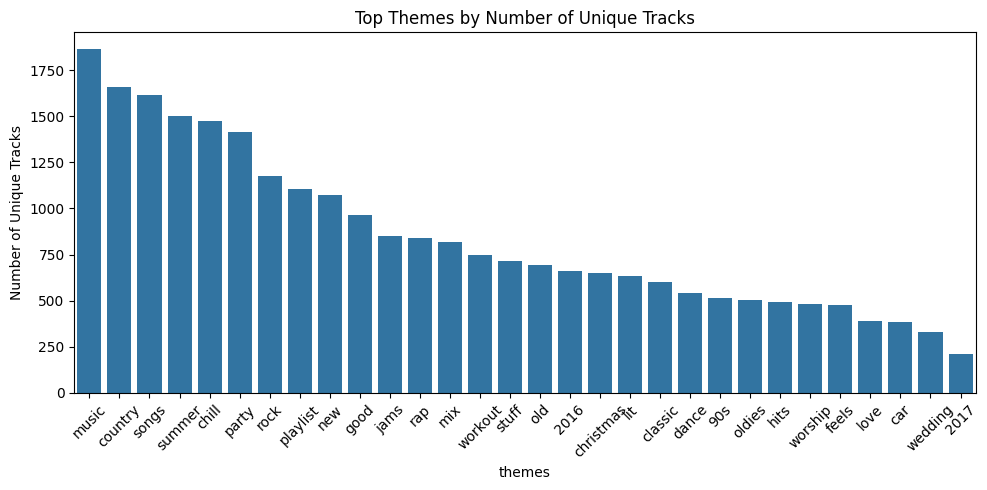

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to database
conn = sqlite3.connect("playlists_dev.db")

# Load staple score table
df = pd.read_sql_query("SELECT * FROM track_theme_staple_scores", conn)

# Count number of unique tracks per theme
theme_counts = df.groupby("themes")["track_uri"].nunique().reset_index(name="unique_tracks")

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=theme_counts.sort_values("unique_tracks", ascending=False), x="themes", y="unique_tracks")
plt.title("Top Themes by Number of Unique Tracks")
plt.ylabel("Number of Unique Tracks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


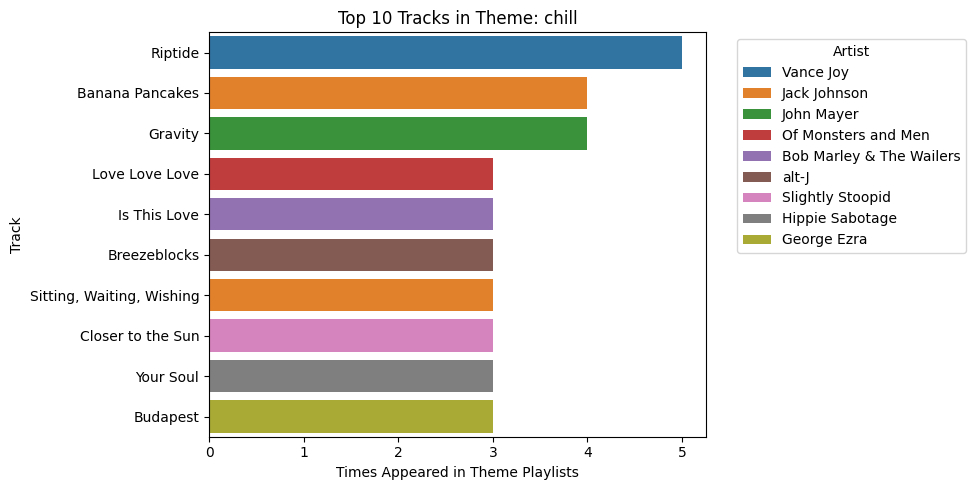

In [ ]:
# Filter for a theme
theme = "chill"
top_tracks = df[df["themes"] == theme].sort_values("count_in_theme_playlists", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_tracks, x="count_in_theme_playlists", y="track_name", hue="artist_name", dodge=False)
plt.title(f"Top 10 Tracks in Theme: {theme}")
plt.xlabel("Times Appeared in Theme Playlists")
plt.ylabel("Track")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


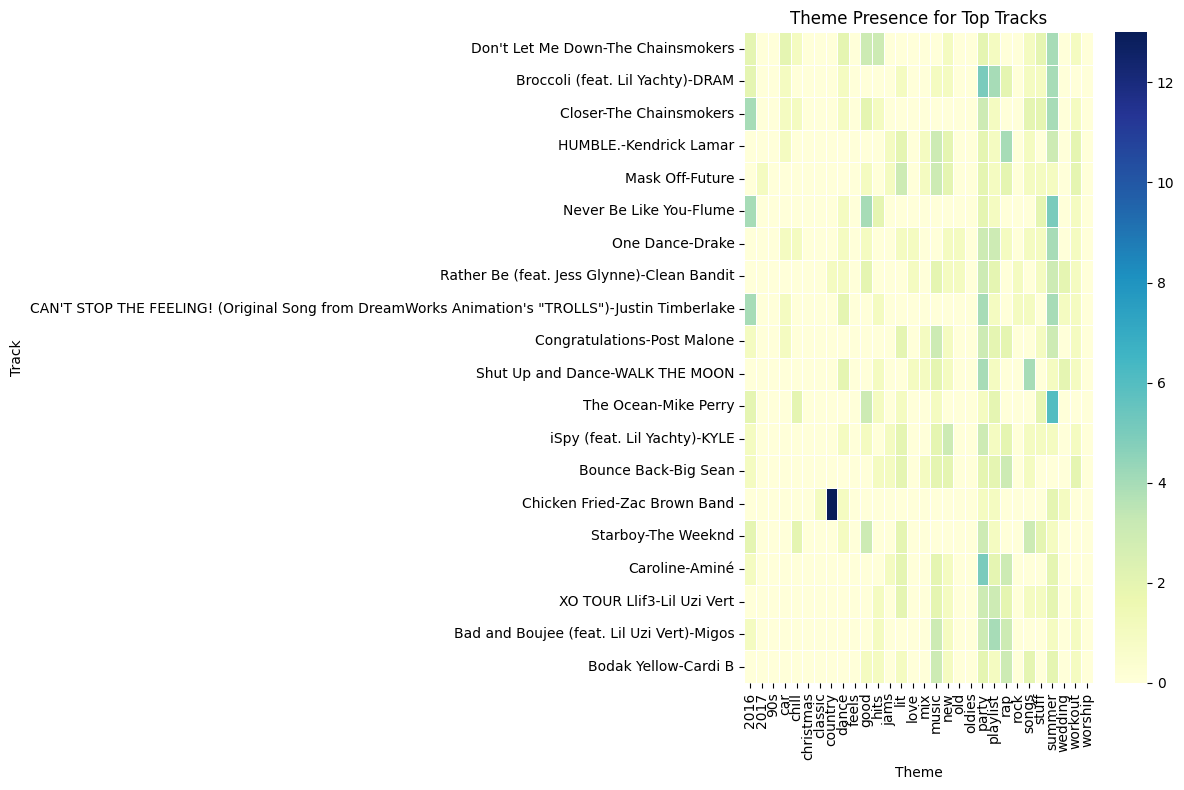

In [13]:
# Pivot to wide format
pivot_df = df.pivot_table(index=["track_name", "artist_name"], columns="themes", values="count_in_theme_playlists", fill_value=0)

# Only keep top N tracks
top_n = 20
top_tracks = df.groupby(["track_name", "artist_name"])["count_in_theme_playlists"].sum().nlargest(top_n).index
filtered_df = pivot_df.loc[top_tracks]

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(filtered_df, cmap="YlGnBu", linewidths=0.5)
plt.title("Theme Presence for Top Tracks")
plt.xlabel("Theme")
plt.ylabel("Track")
plt.tight_layout()
plt.show()
